In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [72]:
# Make the corner plot for the MCMC results
system_name = 'J1042'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [73]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,1.794111,221.8705,-0.834460,-0.086521,0.164068,-39.55220
1,2.276668,221.8745,-0.835224,-0.087175,0.164042,-39.63070
2,6.209614,221.9420,-0.836185,-0.092164,0.166766,-39.55918
3,3.002581,221.8936,-0.836269,-0.087464,0.167006,-39.58776
4,6.294072,221.9192,-0.839622,-0.087683,0.165057,-39.58639
...,...,...,...,...,...,...
2949,6.182680,221.1995,-0.823094,-0.099833,0.190841,-39.57785
2950,9.488760,221.2789,-0.819547,-0.092318,0.186361,-39.62589
2951,7.592757,221.3243,-0.820090,-0.092339,0.195187,-39.64406
2952,5.470101,221.3001,-0.824718,-0.098775,0.191722,-39.67019


In [74]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [75]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

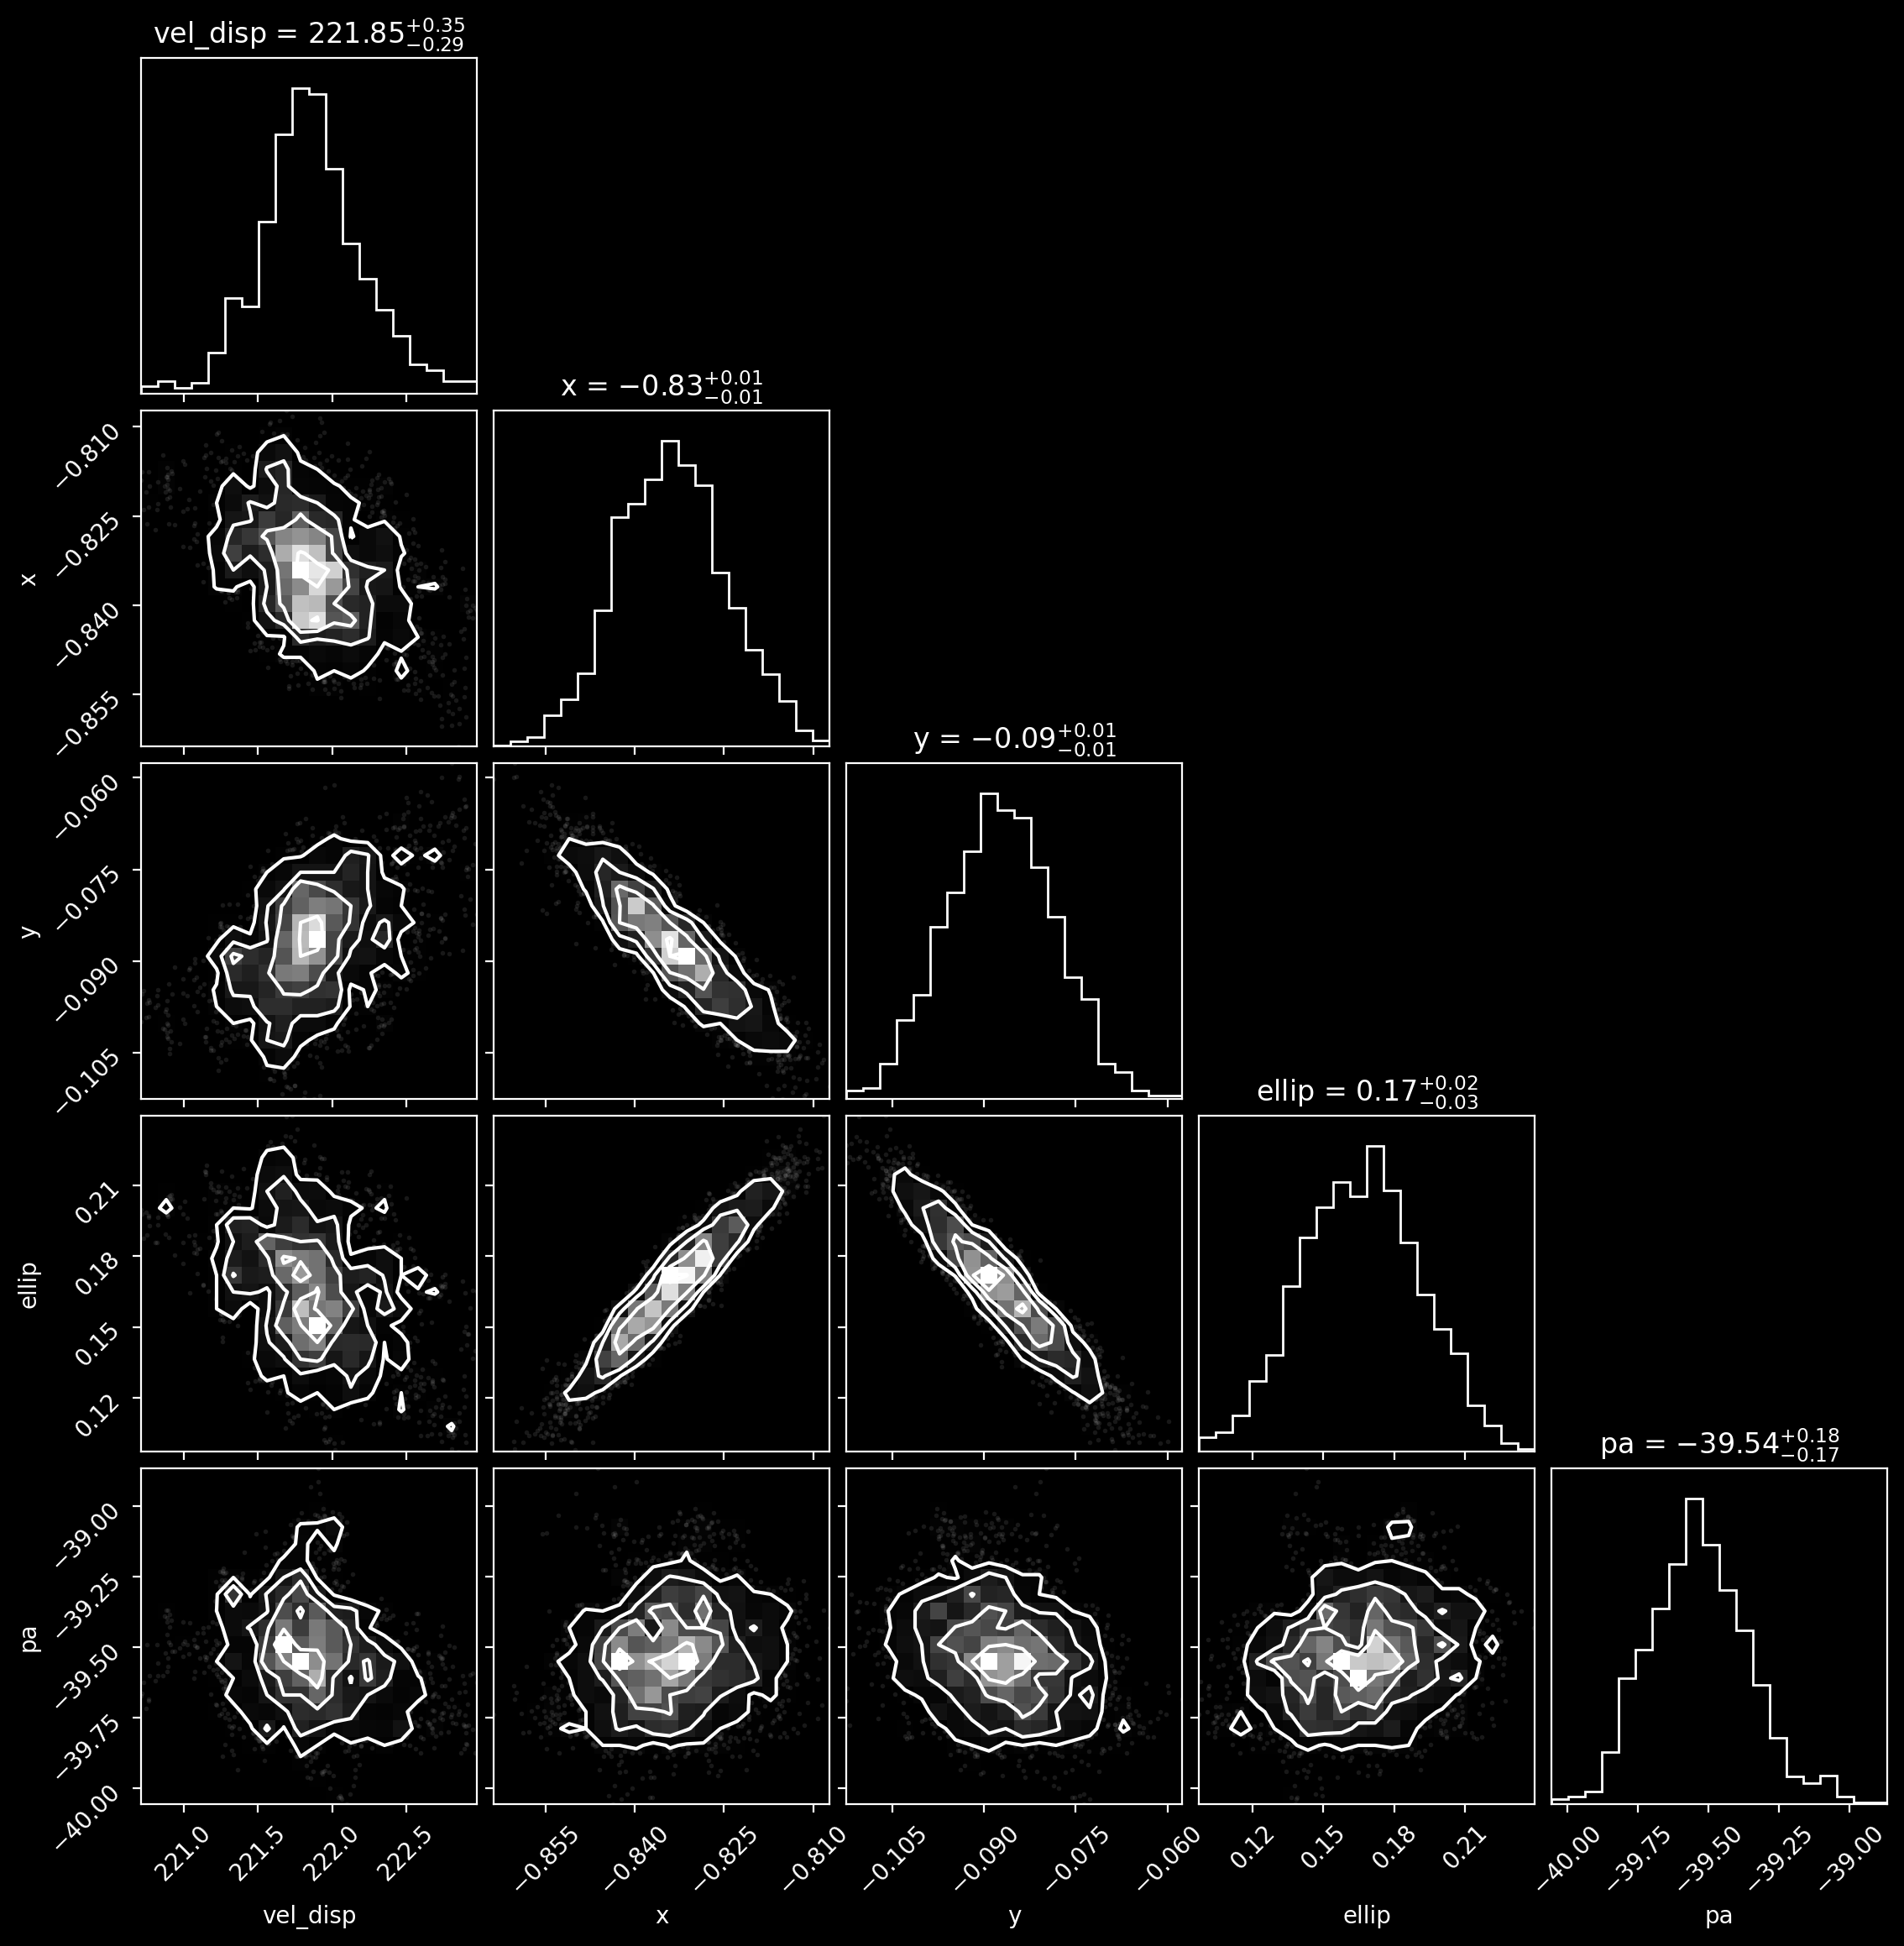

In [76]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')